In [1]:
import math
import time

class ReputationSystem:
    def __init__(self, max_score=1000):
        self.max_score = max_score
        self.users = {}
        self.actions = {
            'verified_review': 1.0,
            'upvoted_review': 2.0,
            'refer_user': 1.5,
            'flagged_review': -1.0,
            'endorse_bad_actor': -3.0,
            'inactivity': 0.0
        }

    def add_user(self, user_id):
        self.users[user_id] = {
            'score': 0,
            'last_action_time': time.time(),  # Time of last action
            'actions_taken': 0
        }

    def perform_action(self, user_id, action):
        if user_id not in self.users:
            print(f"User {user_id} not found!")
            return
        
        user = self.users[user_id]
        
        # Apply action weight
        user['score'] += self.actions.get(action, 0)
        user['actions_taken'] += 1
        user['last_action_time'] = time.time()

        # Apply decay
        self.apply_decay(user_id)

        # Normalize and apply sigmoid
        normalized_score = self.normalize_score(user['score'])
        final_score = self.sigmoid(normalized_score)

        # Output new reputation score
        print(f"User {user_id}'s new reputation score: {final_score:.2f}")

    def apply_decay(self, user_id):
        user = self.users[user_id]
        time_diff = time.time() - user['last_action_time']
        decay_rate = 1.0 / 86400  # Decay rate (1 point per day)

        # Apply decay based on time since last action
        decay = time_diff * decay_rate
        user['score'] -= decay

        # Prevent negative score
        if user['score'] < 0:
            user['score'] = 0

    def normalize_score(self, score):
        # Use logarithmic normalization
        return math.log(1 + score) / math.log(1 + self.max_score)

    def sigmoid(self, x):
        # Sigmoid function to smooth score
        return 1 / (1 + math.exp(-x))

    def get_user_score(self, user_id):
        if user_id not in self.users:
            return None
        user = self.users[user_id]
        normalized_score = self.normalize_score(user['score'])
        return self.sigmoid(normalized_score)

# Example Usage
rep_system = ReputationSystem()

# Add users
rep_system.add_user("user1")
rep_system.add_user("user2")

# Users perform actions
rep_system.perform_action("user1", "verified_review")
rep_system.perform_action("user1", "upvoted_review")
rep_system.perform_action("user2", "flagged_review")

# Get final scores
print(f"Final reputation score for user1: {rep_system.get_user_score('user1'):.2f}")
print(f"Final reputation score for user2: {rep_system.get_user_score('user2'):.2f}")

User user1's new reputation score: 0.53
User user1's new reputation score: 0.55
User user2's new reputation score: 0.50
Final reputation score for user1: 0.55
Final reputation score for user2: 0.50


In [5]:
import pandas as pd
import numpy as np
import random
import time

# Constants
USERS = [f"gooduser{i}" if i % 2 == 0 else f"baduser{i}" for i in range(1, 101)]  # Alternating good and bad users
ACTIONS = ['upvoted_review', 'flagged_review', 'inactivity', 'endorse_bad_actor']
MAX_SCORE = 1.0  # Normalized score range (0 to 1)
DECAY_RATE = 0.1  # Decay rate per action
ENDORSER_THRESHOLD = 0.5  # Score threshold for endorsement eligibility

# Initialize user data
user_data = {user: {'score': 0.5, 'actions': 0} for user in USERS}

# Function to simulate an action
def perform_action(user, action):
    if action == 'upvoted_review':
        return 0.2  # Positive action
    elif action == 'flagged_review':
        return -0.2  # Negative action
    elif action == 'inactivity':
        return -DECAY_RATE  # Decay due to inactivity
    elif action == 'endorse_bad_actor':
        return -0.3  # Negative action from endorsing a bad actor
    return 0

# List to hold simulation log
simulation_log = []

# Run simulation (for 100 actions)
for _ in range(100):
    user = random.choice(USERS)
    action = random.choice(ACTIONS)
    
    # Perform action and update user score
    action_score = perform_action(user, action)
    new_score = user_data[user]['score'] + action_score
    
    # Ensure score stays within bounds [0, MAX_SCORE]
    new_score = max(0, min(MAX_SCORE, new_score))
    
    # Update user data
    user_data[user]['score'] = new_score
    user_data[user]['actions'] += 1

    # Add entry to simulation log
    simulation_log.append({
        'user_id': user,
        'action': action,
        'score': new_score,
        'timestamp': time.time()
    })

# Convert simulation log to DataFrame
log_df = pd.DataFrame(simulation_log)

# Show first few entries
print(log_df.head())

      user_id             action  score     timestamp
0  gooduser44     flagged_review    0.3  1.745225e+09
1   baduser45  endorse_bad_actor    0.2  1.745225e+09
2  gooduser86         inactivity    0.4  1.745225e+09
3   baduser63  endorse_bad_actor    0.2  1.745225e+09
4   baduser51  endorse_bad_actor    0.2  1.745225e+09


In [14]:
import pandas as pd
import numpy as np
import random
import time

# Constants
USERS = [f"gooduser{i}" if i % 2 == 0 else f"baduser{i}" for i in range(1, 101)]  # Alternating good and bad users
ACTIONS = ['upvoted_review', 'flagged_review', 'inactivity', 'endorse_bad_actor']
MAX_SCORE = 1.0  # Normalized score range (0 to 1)
DECAY_RATE = 0.01  # Decay rate per action (small decrement for inactivity)
ENDORSER_THRESHOLD = 0.5  # Score threshold for endorsement eligibility
TIME_UNIT = 1  # Simulate 1 day per action

# Initialize user data
user_data = {user: {'score': 0.5, 'actions': 0, 'last_updated': time.time()} for user in USERS}

# Function to simulate an action
def perform_action(user, action):
    """
    Simulate an action and return the score change.
    """
    if action == 'upvoted_review':
        return 0.2  # Positive action
    elif action == 'flagged_review':
        return -0.2  # Negative action
    elif action == 'inactivity':
        return -DECAY_RATE  # Decay due to inactivity
    elif action == 'endorse_bad_actor':
        return -0.3  # Negative action for endorsing a bad actor
    return 0

# List to hold simulation log
simulation_log = []

# Function to simulate the decay over time
def apply_decay(user):
    """
    Apply decay based on time since last activity.
    """
    current_time = time.time()
    time_passed = current_time - user_data[user]['last_updated']
    decay_amount = DECAY_RATE * (time_passed / TIME_UNIT)  # decay amount based on elapsed time
    return decay_amount

# Run simulation (for 100 actions)
for _ in range(100):
    user = random.choice(USERS)
    action = random.choice(ACTIONS)
    
    # Apply decay
    decay = apply_decay(user)
    user_data[user]['score'] -= decay
    
    # Perform action and update user score
    action_score = perform_action(user, action)
    new_score = user_data[user]['score'] + action_score
    
    # Ensure score stays within bounds [0, MAX_SCORE]
    new_score = max(0, min(MAX_SCORE, new_score))
    
    # Update user data
    user_data[user]['score'] = new_score
    user_data[user]['actions'] += 1
    user_data[user]['last_updated'] = time.time()  # Update the time of last action
    
    # Add entry to simulation log
    simulation_log.append({
        'user_id': user,
        'action': action,
        'score': new_score,
        'decay': decay,
        'timestamp': time.time()
    })

# Convert simulation log to DataFrame
log_df = pd.DataFrame(simulation_log)

# Show first few entries of the log
print(log_df.head())

# If you'd like to see the final state of all users, you can print the final scores:
final_scores = {user: data['score'] for user, data in user_data.items()}
fs = list(final_scores)
fs.sort(key=lambda a: final_scores[a])
print("\nFinal Scores:")
for i in fs:
    print(i,"\t",final_scores[i])

      user_id             action     score     decay     timestamp
0    baduser5     flagged_review  0.299997  0.000003  1.745225e+09
1   baduser45  endorse_bad_actor  0.199997  0.000003  1.745225e+09
2  gooduser52  endorse_bad_actor  0.199998  0.000002  1.745225e+09
3   baduser49         inactivity  0.489998  0.000002  1.745225e+09
4   baduser25     flagged_review  0.299997  0.000003  1.745225e+09

Final Scores:
gooduser2 	 0
baduser15 	 0
gooduser36 	 0
baduser65 	 0
baduser37 	 0.09999634742736813
gooduser40 	 0.17999656915664675
gooduser68 	 0.18999722957611082
baduser77 	 0.18999755859375
baduser61 	 0.18999784946441653
baduser29 	 0.19999644279479983
baduser33 	 0.19999657869338988
gooduser6 	 0.19999702930450441
baduser3 	 0.19999711990356445
gooduser38 	 0.19999715805053714
gooduser82 	 0.19999736070632934
baduser97 	 0.19999753952026367
gooduser98 	 0.19999767065048218
gooduser58 	 0.1999977493286133
gooduser52 	 0.19999840974807742
baduser11 	 0.28999609947204585
gooduser22 	

In [16]:
import pandas as pd
import numpy as np
import random
import time

# Constants
USERS = [f"gooduser{i}" if i % 2 == 0 else f"baduser{i}" for i in range(1, 101)]  # Alternating good and bad users
ACTIONS = ['upvoted_review', 'flagged_review', 'inactivity', 'endorse_bad_actor']
MAX_SCORE = 1.0  # Normalized score range (0 to 1)
DECAY_RATE = 0.01  # Decay rate per action (small decrement for inactivity)
ENDORSER_THRESHOLD = 0.5  # Score threshold for endorsement eligibility
TIME_UNIT = 1  # Simulate 1 day per action
BAD_USER_PENALTY_MULTIPLIER = 1.5  # Scale penalty for bad users

# Initialize user data with a baseline score and timestamp for when they last updated their actions
user_data = {user: {'score': 0.5, 'actions': 0, 'last_updated': time.time()} for user in USERS}

# Function to simulate an action and return the score change
def perform_action(user, action):
    """
    Simulate an action and return the score change.
    """
    if action == 'upvoted_review':
        return 0.2  # Positive action
    elif action == 'flagged_review':
        return -0.2  # Negative action
    elif action == 'inactivity':
        return -DECAY_RATE  # Decay due to inactivity
    elif action == 'endorse_bad_actor':
        return -0.3  # Negative action for endorsing a bad actor
    return 0

# Function to apply scaling for bad users' penalties
def apply_bad_user_penalty(user, action_score):
    """
    Apply a penalty multiplier for bad users to increase the negative impact of their actions.
    """
    if 'baduser' in user:  # Check if the user is a bad user
        return action_score * BAD_USER_PENALTY_MULTIPLIER
    return action_score  # No penalty for good users

# List to hold simulation log
simulation_log = []

# Function to simulate the decay over time (based on last activity)
def apply_decay(user):
    """
    Apply decay based on time since last activity.
    """
    current_time = time.time()
    time_passed = current_time - user_data[user]['last_updated']
    decay_amount = DECAY_RATE * (time_passed / TIME_UNIT)  # decay amount based on elapsed time
    return decay_amount

# Endorsement system that allows users to endorse others based on their reputation
def endorse_user(endorser, endorsee):
    """
    Endorse a user and boost their reputation if the endorser has a high score.
    """
    if user_data[endorser]['score'] >= ENDORSER_THRESHOLD:
        endorsement_score = 0.15  # Boost endorsee's score if endorser is eligible
        user_data[endorsee]['score'] += endorsement_score
        user_data[endorsee]['actions'] += 1
        return endorsement_score
    return 0  # No boost if the endorser has a low score

# Simulate actions for 100 users (for 100 iterations)
for _ in range(100):
    user = random.choice(USERS)
    action = random.choice(ACTIONS)
    
    # Apply decay based on inactivity
    decay = apply_decay(user)
    user_data[user]['score'] -= decay
    
    # Perform action and update user score
    action_score = perform_action(user, action)
    
    # Apply bad user penalty if needed
    action_score = apply_bad_user_penalty(user, action_score)
    
    # If the action is endorsing a bad actor, handle it through endorsement system
    if action == 'endorse_bad_actor':
        action_score += endorse_user(random.choice(USERS), user)
    
    # Update the new score after applying action effects
    new_score = user_data[user]['score'] + action_score
    
    # Ensure score stays within bounds [0, MAX_SCORE]
    new_score = max(0, min(MAX_SCORE, new_score))
    
    # Update user data
    user_data[user]['score'] = new_score
    user_data[user]['actions'] += 1
    user_data[user]['last_updated'] = time.time()  # Update the time of last action
    
    # Add entry to simulation log
    simulation_log.append({
        'user_id': user,
        'action': action,
        'score': new_score,
        'decay': decay,
        'action_score': action_score,
        'timestamp': time.time()
    })

# Convert simulation log to DataFrame
log_df = pd.DataFrame(simulation_log)

# Show first few entries of the log
print(log_df.head())

# If you'd like to see the final state of all users, you can print the final scores:
final_scores = {user: data['score'] for user, data in user_data.items()}

# Sort users by final score
sorted_users = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)

print("\nFinal Scores (sorted by score):")
for user, score in sorted_users:
    print(f"{user}\t{score:.2f}")

      user_id          action     score     decay  action_score     timestamp
0   baduser33  upvoted_review  0.799995  0.000005          0.30  1.745225e+09
1  gooduser58  upvoted_review  0.699995  0.000005          0.20  1.745225e+09
2   gooduser2      inactivity  0.489994  0.000006         -0.01  1.745225e+09
3  gooduser16  upvoted_review  0.699994  0.000006          0.20  1.745225e+09
4   baduser17  flagged_review  0.199994  0.000006         -0.30  1.745225e+09

Final Scores (sorted by score):
baduser33	1.00
gooduser96	0.90
baduser61	0.80
baduser89	0.80
baduser5	0.80
gooduser58	0.70
gooduser16	0.70
gooduser42	0.70
gooduser92	0.70
gooduser84	0.70
gooduser82	0.70
gooduser6	0.70
gooduser62	0.70
gooduser76	0.70
gooduser68	0.70
gooduser52	0.69
gooduser22	0.69
baduser77	0.65
baduser1	0.50
baduser3	0.50
gooduser12	0.50
baduser13	0.50
baduser15	0.50
baduser19	0.50
baduser21	0.50
baduser23	0.50
gooduser26	0.50
gooduser28	0.50
gooduser30	0.50
gooduser34	0.50
gooduser36	0.50
baduser37	0.50
good

In [58]:
import pandas as pd
import numpy as np
import random
import time

# Constants
USERS = [f"gooduser{i}" if i % 2 == 0 else f"baduser{i}" for i in range(1, 101)]  # Alternating good and bad users
ACTIONS = ['upvoted_review', 'flagged_review', 'inactivity', 'endorse_bad_actor']
MAX_SCORE = 1.0  # Normalized score range (0 to 1)
DECAY_RATE = 0.01  # Decay rate per action (small decrement for inactivity)
ENDORSER_THRESHOLD = 0.5  # Score threshold for endorsement eligibility
TIME_UNIT = 1  # Simulate 1 day per action
BAD_USER_PENALTY_MULTIPLIER = 1.5  # Scale penalty for bad users
STAKE_FACTOR = 0.05  # Percentage of current score to stake for each action

# Initialize user data with a baseline score and timestamp for when they last updated their actions
user_data = {user: {'score': 0.5, 'actions': 0, 'last_updated': time.time()} for user in USERS}

# Function to simulate an action and return the score change
def perform_action(user, action):
    """
    Simulate an action and return the score change.
    """
    if action == 'upvoted_review':
        return 0.2  # Positive action
    elif action == 'flagged_review':
        return -0.2  # Negative action
    elif action == 'inactivity':
        return -DECAY_RATE  # Decay due to inactivity
    elif action == 'endorse_bad_actor':
        return -0.3  # Negative action for endorsing a bad actor
    return 0

# Function to apply scaling for bad users' penalties
def apply_bad_user_penalty(user, action_score):
    """
    Apply a penalty multiplier for bad users to increase the negative impact of their actions.
    """
    if 'baduser' in user:  # Check if the user is a bad user
        return action_score * BAD_USER_PENALTY_MULTIPLIER
    return action_score  # No penalty for good users

# List to hold simulation log
simulation_log = []

# Function to simulate the decay over time (based on last activity)
def apply_decay(user):
    """
    Apply decay based on time since last activity.
    """
    current_time = time.time()
    time_passed = current_time - user_data[user]['last_updated']
    decay_amount = DECAY_RATE * (time_passed / TIME_UNIT)  # decay amount based on elapsed time
    return decay_amount

# Endorsement system that allows users to endorse others based on their reputation
def endorse_user(endorser, endorsee):
    """
    Endorse a user and boost their reputation if the endorser has a high score.
    """
    if user_data[endorser]['score'] >= ENDORSER_THRESHOLD:
        endorsement_score = 0.15  # Boost endorsee's score if endorser is eligible
        user_data[endorsee]['score'] += endorsement_score
        user_data[endorsee]['actions'] += 1
        return endorsement_score
    return 0  # No boost if the endorser has a low score

# Simulate actions for 100 users (for 100 iterations)
for _ in range(100):
    user = random.choice(USERS)
    action = random.choice(ACTIONS)
    
    # Apply decay based on inactivity
    decay = apply_decay(user)
    user_data[user]['score'] -= decay
    
    # Perform action and update user score
    action_score = perform_action(user, action)
    
    # Apply bad user penalty if needed
    action_score = apply_bad_user_penalty(user, action_score)
    
    # If the action is endorsing a bad actor, handle it through endorsement system
    if action == 'endorse_bad_actor':
        action_score += endorse_user(random.choice(USERS), user)
    
    # Calculate the stake: a percentage of the user's current score
    stake = user_data[user]['score'] * STAKE_FACTOR
    
    # Adjust the action score by the stake
    action_score -= stake  # Deduct the stake from the action score
    
    # Update the new score after applying action effects and staking
    new_score = user_data[user]['score'] + action_score
    
    # Ensure score stays within bounds [0, MAX_SCORE]
    new_score = max(0, min(MAX_SCORE, new_score))
    
    # Update user data
    user_data[user]['score'] = new_score
    user_data[user]['actions'] += 1
    user_data[user]['last_updated'] = time.time()  # Update the time of last action
    
    # Add entry to simulation log
    simulation_log.append({
        'user_id': user,
        'action': action,
        'score': new_score,
        'decay': decay,
        'action_score': action_score,
        'stake': stake,
        'timestamp': time.time()
    })

# Convert simulation log to DataFrame
log_df = pd.DataFrame(simulation_log)

# Show first few entries of the log
print(log_df.head())

# If you'd like to see the final state of all users, you can print the final scores:
final_scores = {user: data['score'] for user, data in user_data.items()}

# Sort users by final score
sorted_users = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)

print("\nFinal Scores (sorted by score):")
for user, score in sorted_users:
    print(f"{user}\t{score:.2f}")

      user_id             action    score     decay  action_score     stake  \
0   baduser57     flagged_review  0.17499  0.000011     -0.324999  0.024999   
1  gooduser90     upvoted_review  0.67499  0.000011      0.175001  0.024999   
2  gooduser42     flagged_review  0.27499  0.000011     -0.224999  0.024999   
3  gooduser40  endorse_bad_actor  0.46749  0.000011     -0.182499  0.032499   
4   baduser79     flagged_review  0.17499  0.000011     -0.324999  0.024999   

      timestamp  
0  1.745248e+09  
1  1.745248e+09  
2  1.745248e+09  
3  1.745248e+09  
4  1.745248e+09  

Final Scores (sorted by score):
baduser53	1.00
gooduser20	0.84
baduser71	0.77
baduser41	0.77
baduser63	0.77
baduser85	0.77
baduser23	0.77
baduser11	0.77
baduser19	0.77
baduser1	0.74
baduser57	0.71
gooduser56	0.67
gooduser100	0.67
gooduser14	0.67
gooduser36	0.67
gooduser90	0.63
baduser67	0.60
gooduser92	0.59
baduser3	0.50
gooduser6	0.50
baduser7	0.50
gooduser8	0.50
gooduser10	0.50
baduser15	0.50
gooduser24	0.50
ba

In [52]:
import pandas as pd
import numpy as np
import random
import time

# Constants
USERS = [f"gooduser{i}" if i % 2 == 0 else f"baduser{i}" for i in range(1, 101)]  # Alternating good and bad users
ACTIONS = ['upvoted_review', 'flagged_review', 'inactivity', 'endorse_bad_actor', 'review', 'mentor']
MAX_SCORE = 1.0  # Normalized score range (0 to 1)
DECAY_RATE = 0.01  # Decay rate per action (small decrement for inactivity)
ENDORSER_THRESHOLD = 0.5  # Score threshold for endorsement eligibility
TIME_UNIT = 1  # Simulate 1 day per action
BAD_USER_PENALTY_MULTIPLIER = 1.5  # Scale penalty for bad users

# Initialize user data with a baseline score and timestamp for when they last updated their actions
user_data = {user: {'score': 0.5, 'actions': 0, 'last_updated': time.time(), 'sentiment_score': 0.5} for user in USERS}

# Function to simulate an action and return the score change
def perform_action(user, action):
    """
    Simulate an action and return the score change.
    """
    if action == 'upvoted_review':
        return 0.2  # Positive action
    elif action == 'flagged_review':
        return -0.2  # Negative action
    elif action == 'inactivity':
        return -DECAY_RATE  # Decay due to inactivity
    elif action == 'endorse_bad_actor':
        return -0.3  # Negative action for endorsing a bad actor
    elif action == 'review':
        return 0.15  # Positive action for posting a review
    elif action == 'mentor':
        return 0.1  # Reward for mentoring others
    return 0

# Function to apply scaling for bad users' penalties
def apply_bad_user_penalty(user, action_score):
    """
    Apply a penalty multiplier for bad users to increase the negative impact of their actions.
    """
    if 'baduser' in user:  # Check if the user is a bad user
        return action_score * BAD_USER_PENALTY_MULTIPLIER
    return action_score  # No penalty for good users

# Function to apply decay based on time since last action
def apply_decay(user):
    """
    Apply decay based on time since last activity.
    """
    current_time = time.time()
    time_passed = current_time - user_data[user]['last_updated']
    decay_amount = DECAY_RATE * (time_passed / TIME_UNIT)  # decay amount based on elapsed time
    return decay_amount

# Endorsement system that allows users to endorse others based on their reputation
def endorse_user(endorser, endorsee):
    """
    Endorse a user and boost their reputation if the endorser has a high score.
    """
    if user_data[endorser]['score'] >= ENDORSER_THRESHOLD:
        endorsement_score = 0.15  # Boost endorsee's score if endorser is eligible
        user_data[endorsee]['score'] += endorsement_score
        user_data[endorsee]['actions'] += 1
        return endorsement_score
    return 0  # No boost if the endorser has a low score

# Function to evaluate sentiment of a review (simplified)
def analyze_sentiment(review_text):
    """
    A placeholder function for analyzing sentiment of the review.
    For simplicity, we assign a random sentiment score between -1 (negative) and 1 (positive).
    """
    return random.uniform(-1, 1)

# Function for reputation transfer (good users can transfer reputation to others)
def reputation_transfer(transferer, transferee):
    """
    A good user can transfer some of their reputation to another user.
    """
    if user_data[transferer]['score'] > 0.7:  # Only good users can transfer reputation
        transfer_amount = 0.05  # Amount of reputation to transfer
        user_data[transferer]['score'] -= transfer_amount
        user_data[transferee]['score'] += transfer_amount
        return transfer_amount
    return 0

# Function to reward a user for posting a quality review
def reward_for_review(user, action_score, review_text):
    """
    Reward users for posting positive reviews based on the sentiment of the review.
    """
    sentiment_score = analyze_sentiment(review_text)
    if sentiment_score > 0:  # Positive sentiment
        user_data[user]['score'] += 0.1
    else:  # Negative sentiment
        user_data[user]['score'] -= 0.1
    return action_score

# Event-based reputation adjustments (monthly challenges)
def event_based_reputation(user, event_score):
    """
    Apply event-based reputation adjustments, e.g., challenges.
    """
    if event_score > 0:
        user_data[user]['score'] += 0.1  # Reward for high performance
    else:
        user_data[user]['score'] -= 0.1  # Penalty for poor performance
    return event_score

# List to hold simulation log
simulation_log = []

# Simulate actions for 100 users (for 100 iterations)
for _ in range(100):
    user = random.choice(USERS)
    action = random.choice(ACTIONS)
    
    # Apply decay based on inactivity
    decay = apply_decay(user)
    user_data[user]['score'] -= decay
    
    # Perform action and update user score
    action_score = perform_action(user, action)
    
    # Apply bad user penalty if needed
    action_score = apply_bad_user_penalty(user, action_score)
    
    # If the action is endorsing a bad actor, handle it through endorsement system
    if action == 'endorse_bad_actor':
        action_score += endorse_user(random.choice(USERS), user)
    
    # Reward for quality review
    if action == 'review':
        action_score = reward_for_review(user, action_score, "This is a great product!")
    
    # Apply reputation transfer if applicable
    if action == 'mentor':
        action_score += reputation_transfer(user, random.choice(USERS))
    
    # Event-based reputation adjustments
    action_score += event_based_reputation(user, random.choice([1, -1]))  # Random challenge result
    
    # Update the new score after applying action effects
    new_score = user_data[user]['score'] + action_score
    
    # Ensure score stays within bounds [0, MAX_SCORE]
    new_score = max(0, min(MAX_SCORE, new_score))
    
    # Update user data
    user_data[user]['score'] = new_score
    user_data[user]['actions'] += 1
    user_data[user]['last_updated'] = time.time()  # Update the time of last action
    
    # Add entry to simulation log
    simulation_log.append({
        'user_id': user,
        'action': action,
        'score': new_score,
        'decay': decay,
        'action_score': action_score,
        'timestamp': time.time()
    })

# Convert simulation log to DataFrame
log_df = pd.DataFrame(simulation_log)

# Show first few entries of the log
print(log_df.head())

# If you'd like to see the final state of all users, you can print the final scores:
final_scores = {user: data['score'] for user, data in user_data.items()}

# Sort users by final score
sorted_users = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)

print("\nFinal Scores (sorted by score):")
for user, score in sorted_users:
    print(f"{user}\t{score:.2f}")

      user_id             action  score     decay  action_score     timestamp
0  gooduser80             review    0.0  0.000005         -0.85  1.745226e+09
1   baduser69             mentor    1.0  0.000006          1.15  1.745226e+09
2  gooduser64             review    1.0  0.000006          1.15  1.745226e+09
3   baduser47     flagged_review    1.0  0.000006          0.70  1.745226e+09
4  gooduser16  endorse_bad_actor    0.0  0.000006         -1.15  1.745226e+09

Final Scores (sorted by score):
baduser71	1.05
baduser5	1.00
gooduser8	1.00
baduser9	1.00
gooduser10	1.00
baduser15	1.00
baduser17	1.00
baduser19	1.00
gooduser22	1.00
gooduser26	1.00
gooduser32	1.00
baduser37	1.00
gooduser40	1.00
baduser41	1.00
gooduser42	1.00
gooduser50	1.00
baduser51	1.00
gooduser52	1.00
baduser55	1.00
gooduser56	1.00
gooduser60	1.00
gooduser62	1.00
baduser63	1.00
gooduser64	1.00
baduser65	1.00
baduser67	1.00
gooduser72	1.00
baduser77	1.00
gooduser78	1.00
baduser79	1.00
baduser83	1.00
gooduser84	1.00
goodus

In [48]:
import pandas as pd
import numpy as np
import random
import time

# Constants
USERS = [f"gooduser{i}" if i % 2 == 0 else f"baduser{i}" for i in range(1, 101)]  # Alternating good and bad users
ACTIONS = ['upvoted_review', 'flagged_review', 'inactivity', 'endorse_bad_actor', 'review', 'mentor']
MAX_SCORE = 1.0  # Normalized score range (0 to 1)
DECAY_RATE = 0.01  # Decay rate per action (small decrement for inactivity)
ENDORSER_THRESHOLD = 0.5  # Score threshold for endorsement eligibility
TIME_UNIT = 1  # Simulate 1 day per action
BAD_USER_PENALTY_MULTIPLIER = 1.5  # Scale penalty for bad users

# Initialize user data with a baseline score and timestamp for when they last updated their actions
user_data = {user: {'score': 0.5, 'actions': 0, 'last_updated': time.time(), 'sentiment_score': 0.5} for user in USERS}

# Function to simulate an action and return the score change
def perform_action(user, action):
    """
    Simulate an action and return the score change.
    """
    if action == 'upvoted_review':
        return 0.2  # Positive action
    elif action == 'flagged_review':
        return -0.2  # Negative action
    elif action == 'inactivity':
        return -DECAY_RATE  # Decay due to inactivity
    elif action == 'endorse_bad_actor':
        return -0.3  # Negative action for endorsing a bad actor
    elif action == 'review':
        return 0.15  # Positive action for posting a review
    elif action == 'mentor':
        return 0.1  # Reward for mentoring others
    return 0

# Function to apply scaling for bad users' penalties
def apply_bad_user_penalty(user, action_score):
    """
    Apply a penalty multiplier for bad users to increase the negative impact of their actions.
    """
    if 'baduser' in user:  # Check if the user is a bad user
        return action_score * BAD_USER_PENALTY_MULTIPLIER
    return action_score  # No penalty for good users

# Function to apply decay based on time since last action
def apply_decay(user):
    """
    Apply decay based on time since last activity.
    """
    current_time = time.time()
    time_passed = current_time - user_data[user]['last_updated']
    decay_amount = DECAY_RATE * (time_passed / TIME_UNIT)  # decay amount based on elapsed time
    return decay_amount

# Endorsement system that allows users to endorse others based on their reputation
def endorse_user(endorser, endorsee):
    """
    Endorse a user and boost their reputation if the endorser has a high score.
    """
    if user_data[endorser]['score'] >= ENDORSER_THRESHOLD:
        endorsement_score = 0.15  # Boost endorsee's score if endorser is eligible
        user_data[endorsee]['score'] += endorsement_score
        user_data[endorsee]['actions'] += 1
        return endorsement_score
    return 0  # No boost if the endorser has a low score

# Function to evaluate sentiment of a review (simplified)
def analyze_sentiment(review_text):
    """
    A placeholder function for analyzing sentiment of the review.
    For simplicity, we assign a random sentiment score between -1 (negative) and 1 (positive).
    """
    return random.uniform(-1, 1)

# Function for reputation transfer (good users can transfer reputation to others)
def reputation_transfer(transferer, transferee):
    """
    A good user can transfer some of their reputation to another user.
    """
    if user_data[transferer]['score'] > 0.7:  # Only good users can transfer reputation
        transfer_amount = 0.05  # Amount of reputation to transfer
        user_data[transferer]['score'] -= transfer_amount
        user_data[transferee]['score'] += transfer_amount
        return transfer_amount
    return 0

# Function to reward a user for posting a quality review
def reward_for_review(user, action_score, review_text):
    """
    Reward users for posting positive reviews based on the sentiment of the review.
    """
    sentiment_score = analyze_sentiment(review_text)
    if sentiment_score > 0:  # Positive sentiment
        user_data[user]['score'] += 0.1
    else:  # Negative sentiment
        user_data[user]['score'] -= 0.1
    return action_score

# Event-based reputation adjustments (monthly challenges)
def event_based_reputation(user, event_score):
    """
    Apply event-based reputation adjustments, e.g., challenges.
    """
    if event_score > 0:
        user_data[user]['score'] += 0.1  # Reward for high performance
    else:
        user_data[user]['score'] -= 0.1  # Penalty for poor performance
    return event_score

# List to hold simulation log
simulation_log = []

# Simulate actions for 100 users (for 100 iterations)
for _ in range(100):
    user = random.choice(USERS)
    action = random.choice(ACTIONS)
    
    # Apply decay based on inactivity
    decay = apply_decay(user)
    user_data[user]['score'] -= decay
    
    # Perform action and update user score
    action_score = perform_action(user, action)
    
    # Apply bad user penalty if needed
    action_score = apply_bad_user_penalty(user, action_score)
    
    # If the action is endorsing a bad actor, handle it through endorsement system
    if action == 'endorse_bad_actor':
        action_score += endorse_user(random.choice(USERS), user)
    
    # Reward for quality review
    if action == 'review':
        action_score = reward_for_review(user, action_score, "This is a great product!")
    
    # Apply reputation transfer if applicable
    if action == 'mentor':
        action_score += reputation_transfer(user, random.choice(USERS))
    
    # Event-based reputation adjustments
    action_score += event_based_reputation(user, random.choice([1, -1]))  # Random challenge result
    
    # Update the new score after applying action effects
    new_score = user_data[user]['score'] + action_score
    
    # Ensure score stays within bounds [0, MAX_SCORE]
    new_score = max(0, min(MAX_SCORE, new_score))
    
    # Update user data
    user_data[user]['score'] = new_score
    user_data[user]['actions'] += 1
    user_data[user]['last_updated'] = time.time()  # Update the time of last action
    
    # Add entry to simulation log
    simulation_log.append({
        'user_id': user,
        'action': action,
        'score': new_score,
        'decay': decay,
        'action_score': action_score,
        'timestamp': time.time()
    })

# Convert simulation log to DataFrame
log_df = pd.DataFrame(simulation_log)

# Show first few entries of the log
print(log_df.head())

# If you'd like to see the final state of all users, you can print the final scores:
final_scores = {user: data['score'] for user, data in user_data.items()}

# Sort users by final score
sorted_users = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)

print("\nFinal Scores (sorted by score):")
for user, score in sorted_users:
    print(f"{user}\t{score:.2f}")

      user_id             action  score     decay  action_score     timestamp
0   baduser59  endorse_bad_actor    0.0  0.000009        -1.300  1.745226e+09
1  gooduser48             mentor    1.0  0.000009         1.100  1.745226e+09
2   baduser39     flagged_review    1.0  0.000010         0.700  1.745226e+09
3  gooduser12     upvoted_review    0.0  0.000010        -0.800  1.745226e+09
4   baduser55         inactivity    0.0  0.000010        -1.015  1.745226e+09

Final Scores (sorted by score):
baduser71	1.05
gooduser2	1.00
gooduser4	1.00
gooduser8	1.00
baduser9	1.00
gooduser10	1.00
baduser11	1.00
gooduser12	1.00
gooduser16	1.00
baduser27	1.00
gooduser32	1.00
baduser33	1.00
gooduser34	1.00
baduser39	1.00
baduser41	1.00
gooduser44	1.00
gooduser46	1.00
gooduser48	1.00
baduser51	1.00
gooduser54	1.00
gooduser66	1.00
baduser69	1.00
gooduser70	1.00
gooduser72	1.00
gooduser74	1.00
gooduser78	1.00
gooduser80	1.00
gooduser92	1.00
baduser93	1.00
gooduser94	1.00
gooduser98	1.00
baduser95	0.65
ba

In [63]:
a = """
gooduser2 	 0
baduser15 	 0
gooduser36 	 0
baduser65 	 0
baduser37 	 0.09999634742736813
gooduser40 	 0.17999656915664675
gooduser68 	 0.18999722957611082
baduser77 	 0.18999755859375
baduser61 	 0.18999784946441653
baduser29 	 0.19999644279479983
baduser33 	 0.19999657869338988
gooduser6 	 0.19999702930450441
baduser3 	 0.19999711990356445
gooduser38 	 0.19999715805053714
gooduser82 	 0.19999736070632934
baduser97 	 0.19999753952026367
gooduser98 	 0.19999767065048218
gooduser58 	 0.1999977493286133
gooduser52 	 0.19999840974807742
baduser11 	 0.28999609947204585
gooduser22 	 0.28999645948410036
baduser17 	 0.28999660015106205
baduser71 	 0.28999717235565187
gooduser54 	 0.2899972891807556
baduser53 	 0.2899974608421325
gooduser94 	 0.28999822139739984
baduser7 	 0.29999603033065797
baduser9 	 0.2999967789649963
gooduser28 	 0.2999967908859253
gooduser20 	 0.2999970197677612
baduser39 	 0.2999973583221435
baduser85 	 0.2999974012374878
gooduser60 	 0.29999757051467896
gooduser86 	 0.2999976015090942
baduser93 	 0.29999801158905026
gooduser90 	 0.38999733686447147
gooduser8 	 0.3999961113929749
baduser45 	 0.3999968004226685
gooduser78 	 0.39999765872955323
gooduser24 	 0.47999608039855957
baduser49 	 0.4799973702430725
baduser55 	 0.47999768018722533
baduser35 	 0.4899962520599365
gooduser10 	 0.48999634027481076
gooduser44 	 0.4899966597557068
gooduser30 	 0.4899967813491821
baduser19 	 0.4899968314170837
baduser43 	 0.48999714851379395
baduser57 	 0.4899973702430725
gooduser84 	 0.48999763011932373
gooduser88 	 0.4899978232383728
gooduser46 	 0.48999796152114866
gooduser96 	 0.4899983525276184
baduser5 	 0.4999964213371277
baduser25 	 0.4999964213371277
baduser1 	 0.5
gooduser4 	 0.5
gooduser12 	 0.5
baduser13 	 0.5
gooduser14 	 0.5
gooduser16 	 0.5
gooduser18 	 0.5
baduser23 	 0.5
gooduser26 	 0.5
gooduser32 	 0.5
gooduser34 	 0.5
gooduser42 	 0.5
baduser47 	 0.5
gooduser50 	 0.5
baduser51 	 0.5
gooduser56 	 0.5
baduser59 	 0.5
gooduser62 	 0.5
baduser63 	 0.5
gooduser64 	 0.5
gooduser66 	 0.5
baduser67 	 0.5
baduser69 	 0.5
gooduser72 	 0.5
baduser73 	 0.5
baduser75 	 0.5
baduser79 	 0.5
gooduser80 	 0.5
baduser87 	 0.5
baduser91 	 0.5
baduser95 	 0.5
baduser21 	 0.6799962782859801
baduser41 	 0.699996817111969
baduser27 	 0.6999969720840454
baduser89 	 0.6999971628189088
baduser31 	 0.6999972009658814
gooduser48 	 0.6999974894523621
gooduser70 	 0.6999977612495423
gooduser100 	 0.6999977684020996
gooduser76 	 0.6999979209899903
gooduser92 	 0.699997980594635
baduser99 	 0.6999980902671814
baduser81 	 0.6999980998039246
baduser83 	 0.6999983501434326
gooduser74 	 0.8999973106384278
"""
fl = list(a.split())
n = fl[::2][::-1]
x = fl[1::2][::-1]

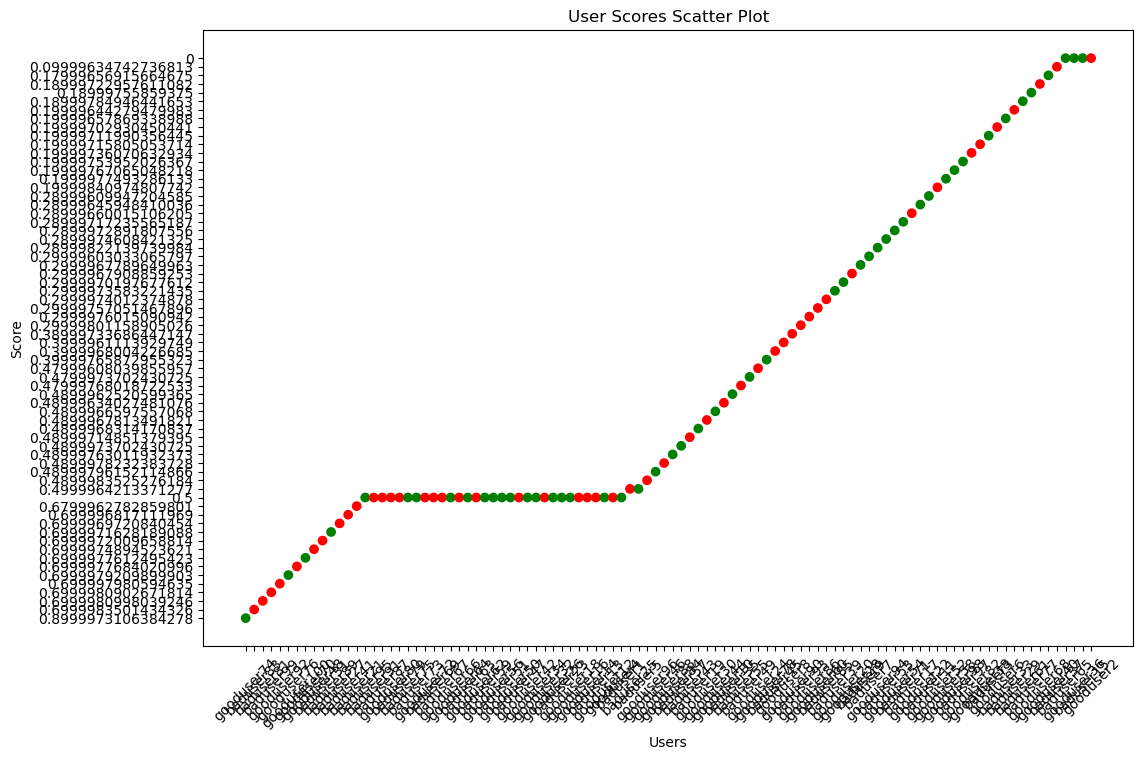

In [64]:
# Scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(n, x, color=['green' if 'good' in user else 'red' for user in users])

# Add labels and title
plt.xlabel('Users')
plt.ylabel('Score')
plt.title('User Scores Scatter Plot')

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Show plot
plt.show()

In [20]:
len(values)

92

In [24]:
print(n)
print(x)

['baduser33', 'gooduser96', 'baduser61', 'baduser89', 'baduser5', 'gooduser58', 'gooduser16', 'gooduser42', 'gooduser92', 'gooduser84', 'gooduser82', 'gooduser6', 'gooduser62', 'gooduser76', 'gooduser68', 'gooduser52', 'gooduser22', 'baduser77', 'baduser1', 'baduser3', 'gooduser12', 'baduser13', 'baduser15', 'baduser19', 'baduser21', 'baduser23', 'gooduser26', 'gooduser28', 'gooduser30', 'gooduser34', 'gooduser36', 'baduser37', 'gooduser40', 'baduser43', 'gooduser44', 'gooduser50', 'baduser53', 'baduser55', 'gooduser56', 'baduser59', 'baduser63', 'gooduser64', 'baduser65', 'gooduser72', 'baduser73', 'gooduser74', 'baduser75', 'gooduser86', 'gooduser88', 'gooduser90', 'baduser91', 'gooduser94', 'baduser95', 'baduser97', 'gooduser98', 'gooduser54', 'gooduser70', 'baduser93', 'baduser79', 'gooduser38', 'gooduser46', 'gooduser2', 'gooduser80', 'gooduser66', 'gooduser48', 'baduser83', 'baduser31', 'baduser29', 'baduser81', 'gooduser14', 'baduser35', 'baduser57', 'baduser9', 'gooduser24', 'g